## Error mitigation: Building confidence

In [1]:
import numpy as np

from qiskit.circuit.library import efficient_su2
from qiskit.transpiler import CouplingMap
from qiskit.synthesis import LieTrotter
from qiskit.quantum_info import SparsePauliOp
from qiskit_addon_utils.problem_generators import (
    generate_time_evolution_circuit,
    generate_xyz_hamiltonian,
)

We consider two different circuits of different types -- a compact Hamiltonian simulation circuit, and a sparse EfficientSU2 circuit. The same observable $\frac{1}{n} \sum_{i=1}^n Z_i$ is selected for both the circuits.

In [2]:
num_qubits = 30

In [3]:
observable = SparsePauliOp.from_list(
    [
        "I"*i+"Z"+"I"*(num_qubits-i-1), 1/num_qubits
    ] for i in range(num_qubits)
)
observable

SparsePauliOp(['ZIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IZIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIZIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIZIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIZIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIZIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIZIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIZIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIZIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIZIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIZIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIZIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIZIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIZIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIZIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIZIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIZIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIZIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIZIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIZIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIZIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIZIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIZIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIZIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIZIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIZIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIZII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIZI',

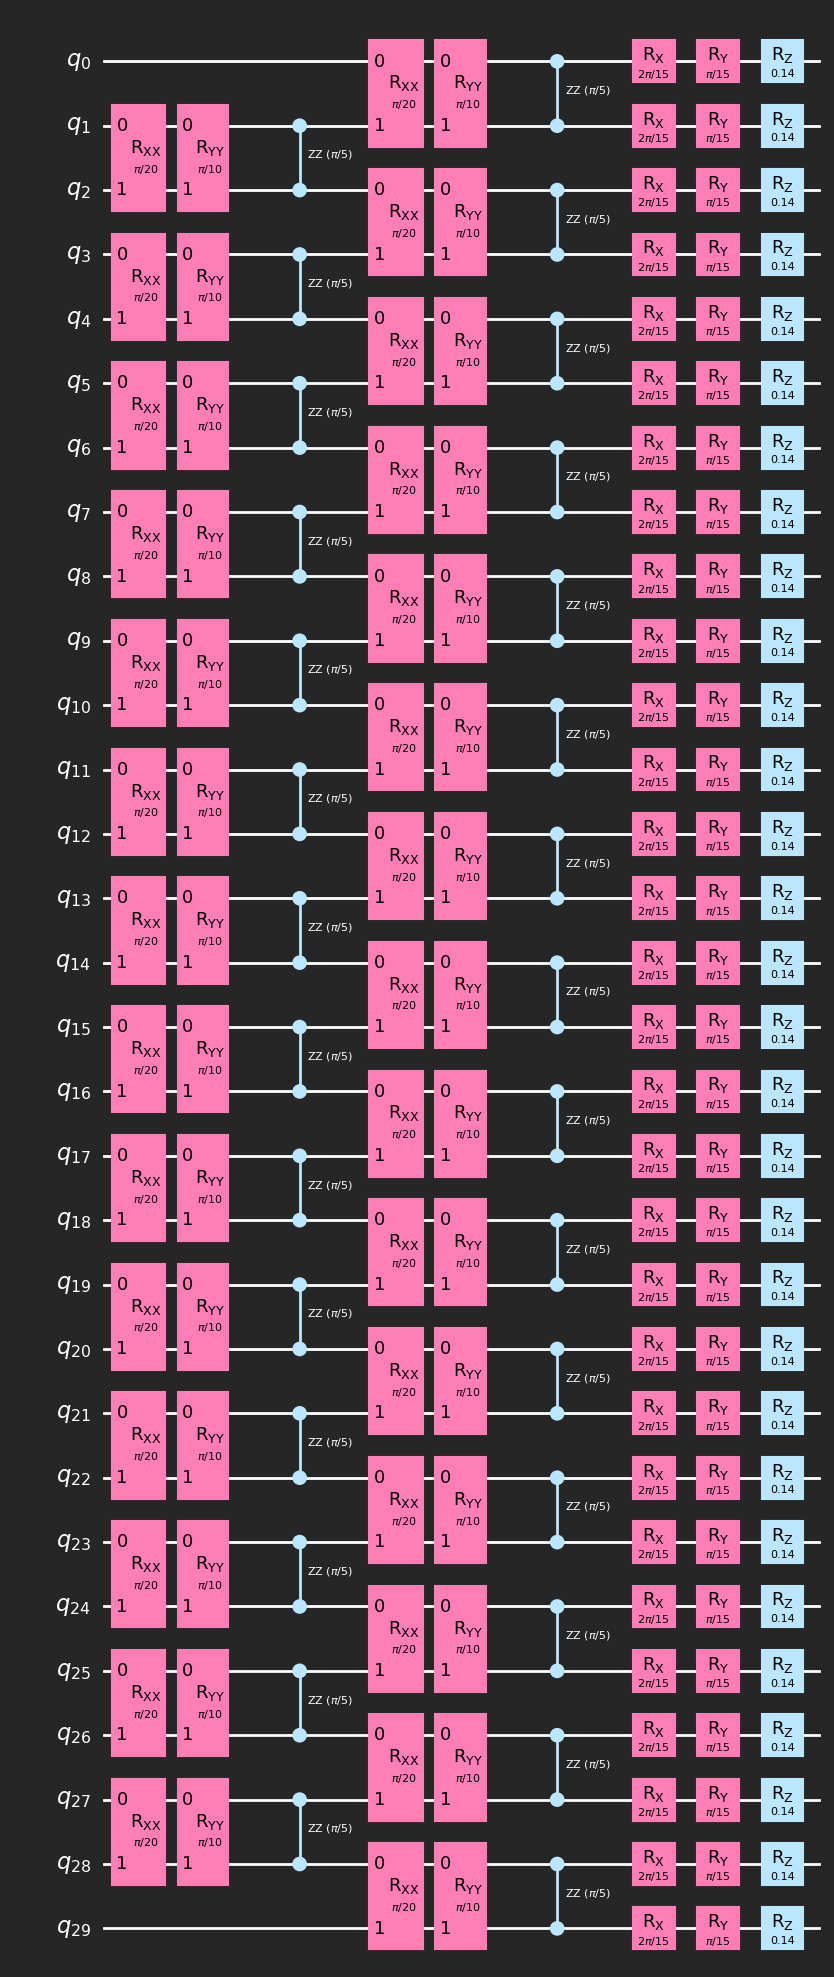

In [4]:

coupling_map = CouplingMap.from_line(num_qubits, bidirectional=True)

hamiltonian = generate_xyz_hamiltonian(
    coupling_map,
    coupling_constants=(np.pi / 8, np.pi / 4, np.pi / 2),
    ext_magnetic_field=(np.pi / 3, np.pi / 6, np.pi / 9),
)

# we evolve for some time
hs_circuit = generate_time_evolution_circuit(
    hamiltonian, synthesis=LieTrotter(reps=1), time=0.2
)


hs_circuit.draw("mpl", fold=-1, style='iqp-dark')

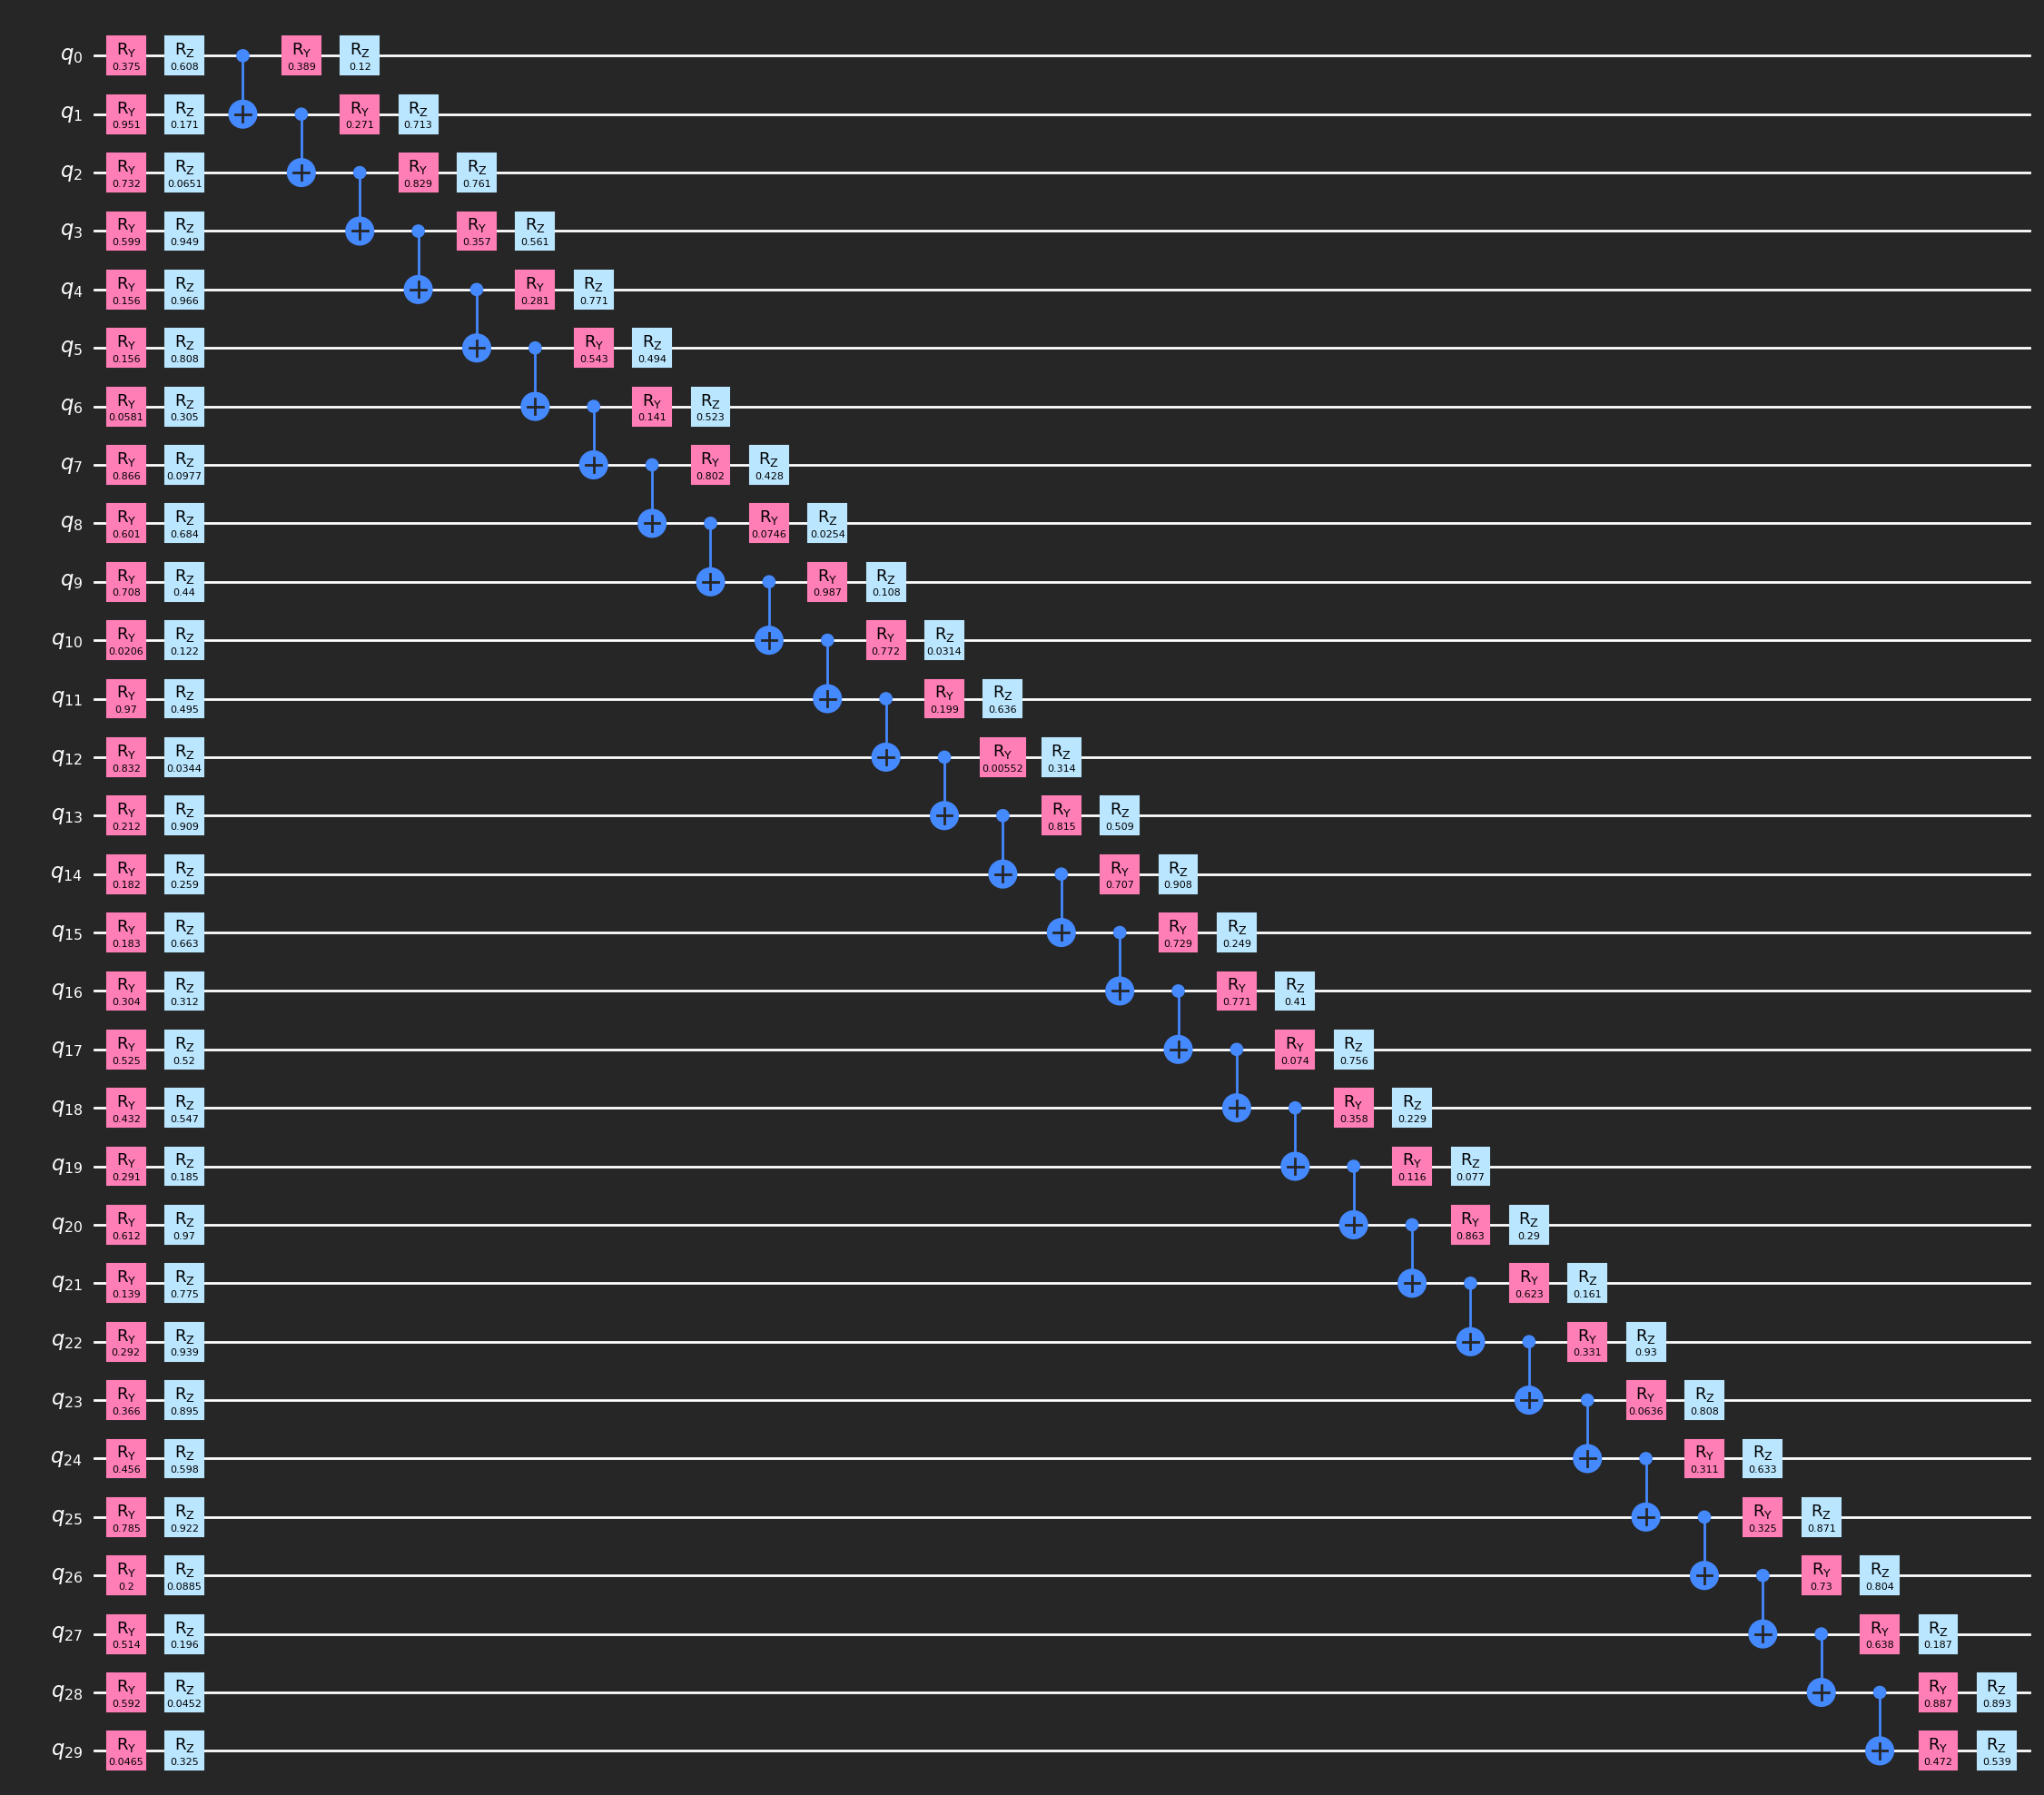

In [5]:
su2_circuit = efficient_su2(num_qubits, entanglement='linear', reps=1)

np.random.seed(42) # random seed for reproducibility
params = np.random.rand(su2_circuit.num_parameters)
su2_circuit.assign_parameters(params, inplace=True)

su2_circuit.draw("mpl", fold=-1, style='iqp-dark')

### Ideal simulation

In [6]:
from qiskit_ibm_runtime import EstimatorV2
from qiskit_aer import AerSimulator

simulator = EstimatorV2(mode=AerSimulator())

In [7]:
hs_ideal = simulator.run([(hs_circuit, observable)])
su2_ideal = simulator.run([(su2_circuit, observable)])

hs_ideal_result = hs_ideal.result()[0]
su2_ideal_result = su2_ideal.result()[0]

hs_ideal_expval = hs_ideal_result.data.evs
su2_ideal_expval = su2_ideal_result.data.evs

In [8]:
print(f'Ideal expectation value of the hamiltonian simulation circuit: {hs_ideal_expval}')
print(f'Ideal expectation value of the EfficientSU2 circuit: {su2_ideal_expval}')

Ideal expectation value of the hamiltonian simulation circuit: 0.8730305989583336
Ideal expectation value of the EfficientSU2 circuit: 0.08059895833333333


### Create Clifford PUBs using NEAT

In [9]:
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2, Batch
service = QiskitRuntimeService(channel="ibm_cloud",
                               instance="crn:v1:bluemix:public:quantum-computing:us-east:a/6c63dae5281147f1a0449b36e0aaba3a:20efd56a-3db0-4aa6-9c69-2686147fcb87::"
                               )
backend = service.least_busy(operational=True, simulator=False)
backend

<IBMBackend('ibm_kingston')>

In [10]:
from qiskit.transpiler import generate_preset_pass_manager
pm = generate_preset_pass_manager(optimization_level=3, target=backend.target)

In [11]:
isa_hs_circuit = pm.run(hs_circuit)
isa_hs_observable = observable.apply_layout(isa_hs_circuit.layout)

isa_su2_circuit = pm.run(su2_circuit)
isa_su2_observable = observable.apply_layout(isa_su2_circuit.layout)


pubs = [(isa_hs_circuit, isa_hs_observable),(isa_su2_circuit, isa_su2_observable)]

In [12]:
from qiskit_ibm_runtime.debug_tools import Neat
analyzer = Neat(backend)

In [13]:
clifford_pubs = analyzer.to_clifford(pubs)

#### Ideal expval of clifford pubs

In [14]:
clifford_ideal_results = analyzer.ideal_sim(clifford_pubs, seed_simulator=10)
#clifford_su2_ideal_result = analyzer.ideal_sim(pubs[1], seed_simulator=10)

print(f'Ideal value of clifford HS circuits is {clifford_ideal_results[0]}')
print(f'Ideal value of clifford SU2 circuits is {clifford_ideal_results[1]}')

Ideal value of clifford HS circuits is NeatPubResult(vals=array(1.))
Ideal value of clifford SU2 circuits is NeatPubResult(vals=array(0.03333333))


The different techniques that we shall try:

1. Readout error mitigation is always active
2. Gate twirling is always active
3. ZNE with noise factors (1,3,5), (1,2,3), (1,1.2,1.4), (1,1.1,1.2)
4. Repeat step 3 with dynamical decoupling with XpXm pulse

In [15]:
jobs = []

with Batch(backend=backend) as batch:
    estimator = EstimatorV2(mode=batch)
    estimator.options.default_shots = 6000
    estimator.options.resilience_level = 0 # disable all error mitigation to begin with

    # add readout error mitigation
    estimator.options.resilience.measure_mitigation = True

    # add gate twirling
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    # turn on ZNE
    estimator.options.resilience.zne_mitigation = True
    estimator.options.resilience.zne.extrapolator = ("exponential", "linear")

    # execute with 4 different noise factors
    noise_factors = [
        (1,3,5),
        (1,2,3),
        (1,1.2,1.4),
        (1,1.1,1.2)
    ]
    for nf in noise_factors:
        estimator.options.resilience.zne.noise_factors = nf
        jobs.append(estimator.run(clifford_pubs))

    # turn on dynamical decoupling
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XpXm"

    # rerun zne with dynamical decoupling
    for nf in noise_factors:
        estimator.options.resilience.zne.noise_factors = nf
        jobs.append(estimator.run(clifford_pubs))

In [16]:
jobs

[<RuntimeJobV2('d2dhl2uaa61s73eeg9rg', 'estimator')>,
 <RuntimeJobV2('d2dhl3hncmis73a3s2e0', 'estimator')>,
 <RuntimeJobV2('d2dhl42d065c73fe53vg', 'estimator')>,
 <RuntimeJobV2('d2dhl4uaa61s73eeg9u0', 'estimator')>,
 <RuntimeJobV2('d2dhl58f4s4s73dgfagg', 'estimator')>,
 <RuntimeJobV2('d2dhl66aa61s73eeg9vg', 'estimator')>,
 <RuntimeJobV2('d2dhl6gf4s4s73dgfai0', 'estimator')>,
 <RuntimeJobV2('d2dhl70f4s4s73dgfajg', 'estimator')>]

In [37]:
def relative_error(ideal, experimental):
    """Calculate the relative error between the result and the ideal value."""
    diff = np.abs(ideal - experimental)/ideal
    return np.round(diff*100, 2)

In [40]:
# Obtain relative error for Hamiltonian simulation circuit
relative_error_hs = [
    relative_error(clifford_ideal_results._pub_results[0].vals, jobs[i].result()[0].data.evs)
    for i in range(len(jobs))
]


# Obtain relative error for EfficientSU2 circuit
relative_error_su2 = [
    relative_error(clifford_ideal_results._pub_results[1].vals, jobs[i].result()[1].data.evs)
    for i in range(len(jobs))
]

In [41]:
relative_error_hs

[np.float64(1.54),
 np.float64(1.38),
 np.float64(1.65),
 np.float64(2.31),
 np.float64(1.74),
 np.float64(1.65),
 np.float64(4.53),
 np.float64(7.09)]

In [42]:
relative_error_su2

[np.float64(5.81),
 np.float64(4.1),
 np.float64(86.39),
 np.float64(83.27),
 np.float64(32.67),
 np.float64(9.57),
 np.float64(124.96),
 np.float64(213.68)]

In [44]:
estimator = EstimatorV2(mode=backend)
estimator.options.default_shots = 6000
estimator.options.resilience_level = 0 # disable all error mitigation to begin with

# add readout error mitigation
estimator.options.resilience.measure_mitigation = True

# add gate twirling
estimator.options.twirling.enable_gates = True
estimator.options.twirling.num_randomizations = "auto"

# turn on ZNE
estimator.options.resilience.zne_mitigation = True
estimator.options.resilience.zne.extrapolator = ("exponential", "linear")
estimator.options.resilience.zne.noise_factors = (1,2,3)

In [ ]:
job = estimator.run(pubs)

In [47]:
job_id = job.job_id()
print(job_id)

d2dhqkgf4s4s73dgfg70


In [48]:
expval_hs = job.result()[0].data.evs
expval_su2 = job.result()[1].data.evs

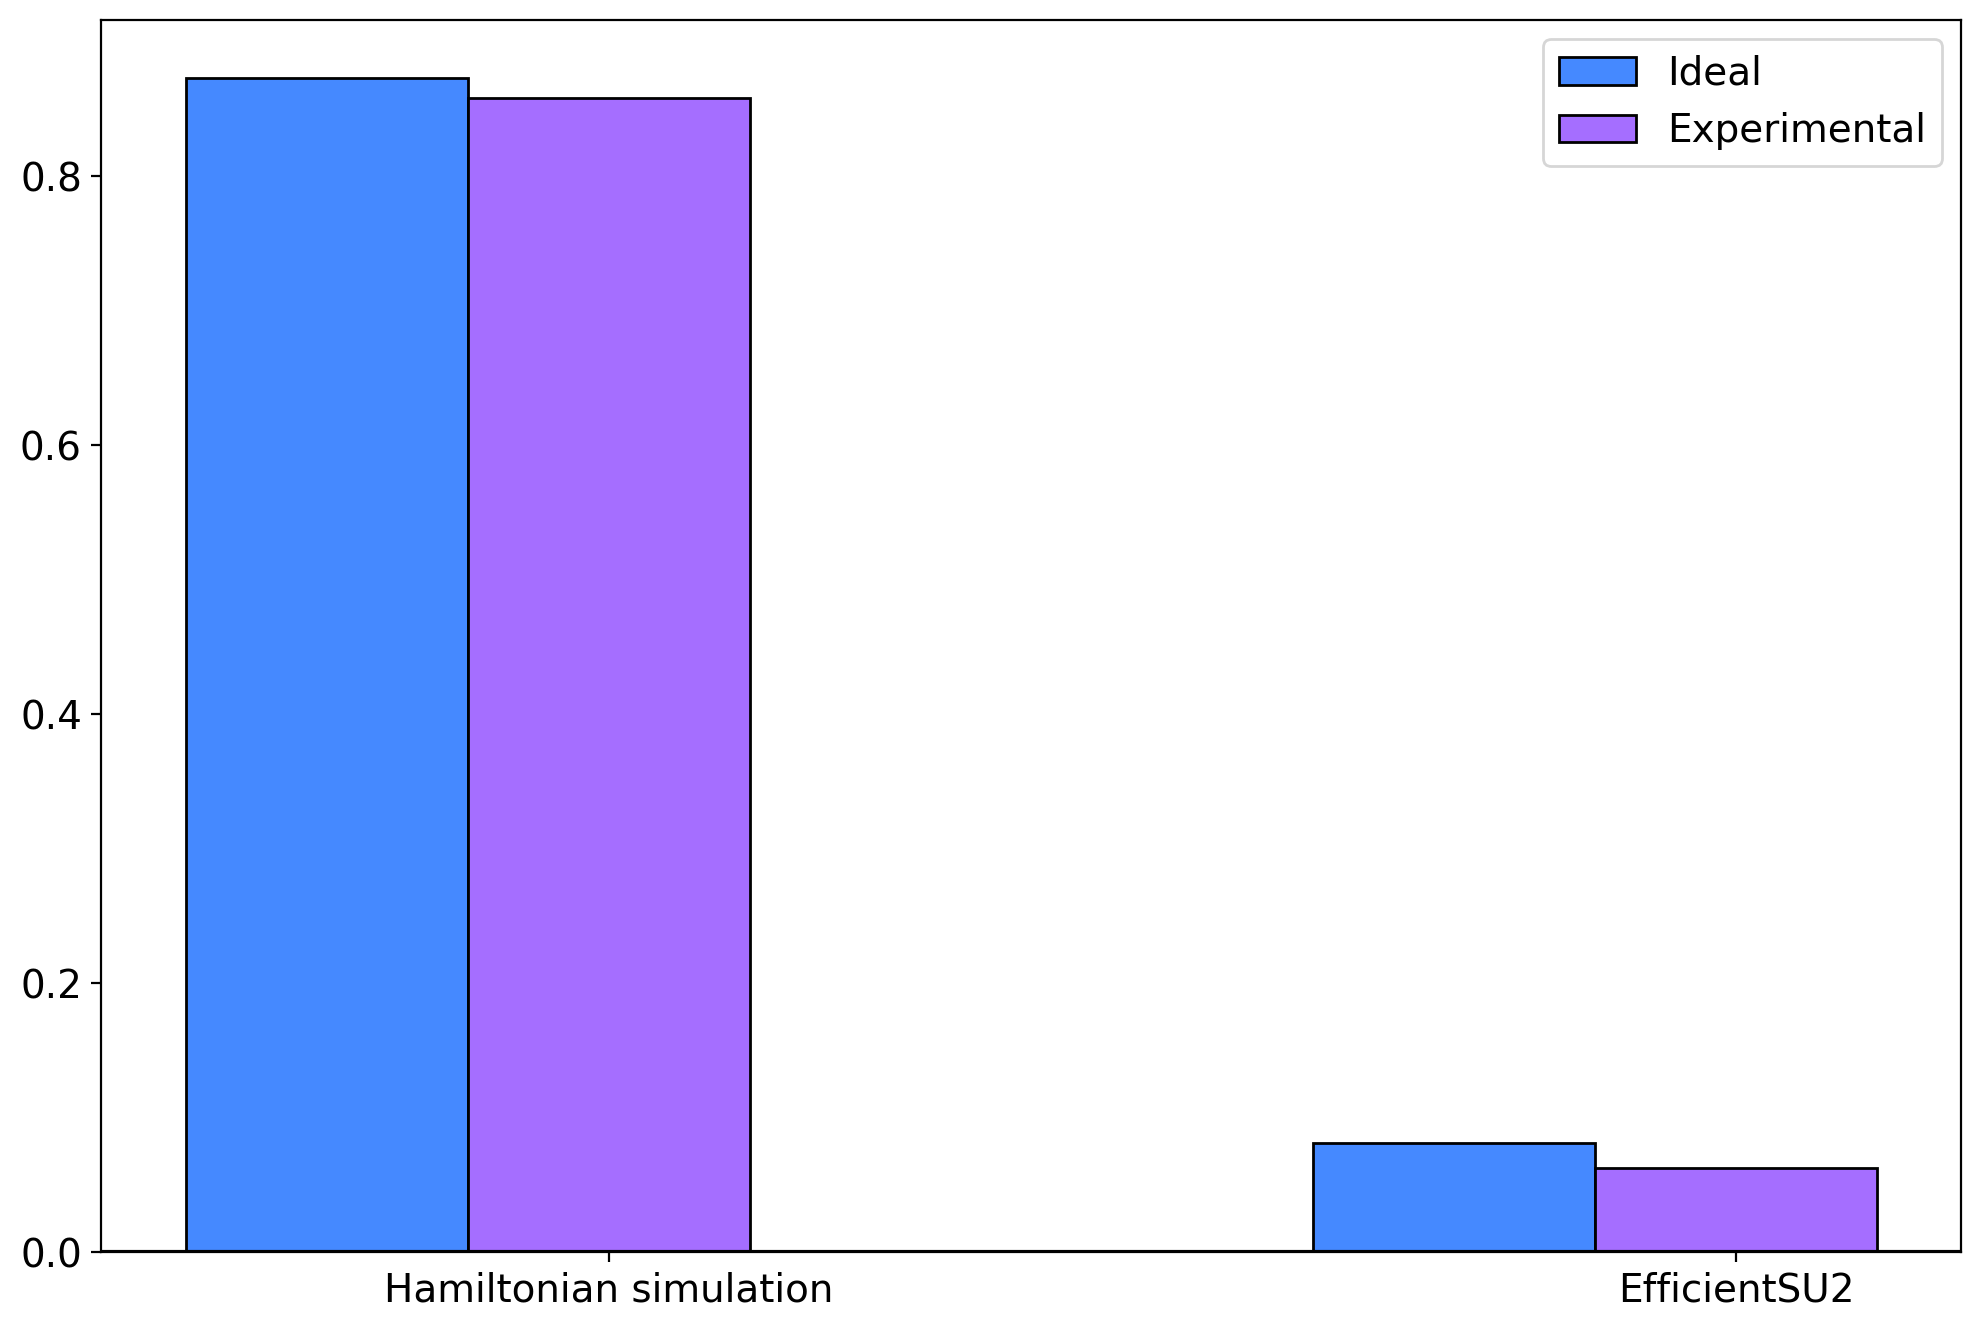

In [ ]:
import matplotlib.pyplot as plt

fig = plt.subplots(figsize=(12, 8), dpi=200)
width = 0.25
labels = ["Hamiltonian simulation", "EfficientSU2"]
x = np.arange(len(labels))
 
ideal = [hs_ideal_expval, su2_ideal_expval]
experimental = [expval_hs, expval_su2]
 
br1 = np.arange(len(ideal))
br2 = [x + width for x in br1]
 
plt.bar(
    br1, ideal, width=width, edgecolor="k", label="Ideal", color="#4589ff"
)
plt.bar(br2, experimental, width=width, edgecolor="k", label="Experimental", color="#a56eff")
 
plt.axhline(y=0, color="k", linestyle="-")
 
plt.xticks([r + width for r in range(len(ideal))], labels, fontsize=14)
plt.yticks(fontsize=14)
 
plt.legend(fontsize=14)
plt.show()
